In [1]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to our database
conn = sqlite3.connect('../database/nhl.db')

# Pull skater stats from NHL API
response = requests.get("https://api-web.nhle.com/v1/skater-stats-leaders/20252026/2?limit=-1")
print(response.status_code)
print(response.json().keys())

200
dict_keys(['goalsSh', 'plusMinus', 'assists', 'goalsPp', 'faceoffLeaders', 'penaltyMins', 'goals', 'points', 'toi'])


In [5]:
response.json()['points'][0]

{'id': 8478402,
 'firstName': {'default': 'Connor'},
 'lastName': {'default': 'McDavid'},
 'sweaterNumber': 97,
 'headshot': 'https://assets.nhle.com/mugs/nhl/20252026/EDM/8478402.png',
 'teamAbbrev': 'EDM',
 'teamName': {'default': 'Oilers'},
 'teamLogo': 'https://assets.nhle.com/logos/nhl/svg/EDM_light.svg',
 'position': 'C',
 'value': 138}

In [14]:
df_points = pd.DataFrame(response.json()['points'])
df_points["first_name"] = df_points["firstName"].apply(lambda x: x['default'])
df_points["last_name"] = df_points["lastName"].apply(lambda x: x['default'])
df_points["team_name"] = df_points["teamName"].apply(lambda x: x['default'])
df_points = df_points.drop(columns=['headshot','teamLogo','firstName','lastName','teamName'])
df_points.rename(columns={'value': 'points'}, inplace=True)


df_goals = pd.DataFrame(response.json()['goals'])
df_goals["first_name"] = df_goals["firstName"].apply(lambda x: x['default'])
df_goals["last_name"] = df_goals["lastName"].apply(lambda x: x['default'])
df_goals["team_name"] = df_goals["teamName"].apply(lambda x: x['default'])
df_goals = df_goals.drop(columns=['headshot','teamLogo','firstName','lastName','teamName'])
df_goals.rename(columns={'value': 'goals'}, inplace=True)
df_goals.head()

df_assists = pd.DataFrame(response.json()['assists'])
df_assists["first_name"] = df_assists["firstName"].apply(lambda x: x['default'])
df_assists["last_name"] = df_assists["lastName"].apply(lambda x: x['default'])
df_assists["team_name"] = df_assists["teamName"].apply(lambda x: x['default'])
df_assists = df_assists.drop(columns=['headshot','teamLogo','firstName','lastName','teamName'])
df_assists.rename(columns={'value': 'assist'}, inplace=True)

df_assists.head()


,id,sweaterNumber,teamAbbrev,position,assist,first_name,last_name,team_name
0,8478402,97.0,EDM,C,90,Connor,McDavid,Oilers
1,8476453,86.0,TBL,R,86,Nikita,Kucherov,Lightning
2,8477492,29.0,COL,C,74,Nathan,MacKinnon,Avalanche
3,8480803,2.0,EDM,D,74,Evan,Bouchard,Oilers
4,8480018,14.0,MTL,C,72,Nick,Suzuki,Canadiens


In [ ]:
df_players = pd.merge(df_points, df_goals, on='id')
df_players = pd.merge(df_players, df_assists, on='id')

In [18]:
df_players.columns

Index(['id', 'sweaterNumber_x', 'teamAbbrev_x', 'position_x', 'points',
       'first_name_x', 'last_name_x', 'team_name_x', 'sweaterNumber_y',
       'teamAbbrev_y', 'position_y', 'goals', 'first_name_y', 'last_name_y',
       'team_name_y', 'sweaterNumber', 'teamAbbrev', 'position', 'assist',
       'first_name', 'last_name', 'team_name'],
      dtype='str')

In [19]:
df_players = df_players[['id', 'first_name_x', 'last_name_x', 'teamAbbrev_x', 'position_x', 'points', 'goals', 'assist']]

df_players.rename(columns={
    'first_name_x': 'first_name',
    'last_name_x': 'last_name',
    'teamAbbrev_x': 'team',
    'position_x': 'position',
    'assist': 'assists'
}, inplace=True)

print(df_players.shape)
df_players.head()

(718, 8)


,id,first_name,last_name,team,position,points,goals,assists
0,8478402,Connor,McDavid,EDM,C,138,48,90
1,8476453,Nikita,Kucherov,TBL,R,130,44,86
2,8477492,Nathan,MacKinnon,COL,C,127,53,74
3,8484801,Macklin,Celebrini,SJS,C,115,45,70
4,8476460,Mark,Scheifele,WPG,C,103,36,67


In [20]:
df_players.to_sql('players', conn, if_exists='replace', index=False)
print("Players table written to database!")

Players table written to database!


In [23]:
query = """
    SELECT first_name, last_name, team, position, points, goals, assists
    FROM players
    ORDER BY points DESC
"""

df_player_query = pd.read_sql_query(query, conn)
df_player_query.head(10)

,first_name,last_name,team,position,points,goals,assists
0,Connor,McDavid,EDM,C,138,48,90
1,Nikita,Kucherov,TBL,R,130,44,86
2,Nathan,MacKinnon,COL,C,127,53,74
3,Macklin,Celebrini,SJS,C,115,45,70
4,Mark,Scheifele,WPG,C,103,36,67
5,Nick,Suzuki,MTL,C,101,29,72
6,Martin,Necas,COL,C,100,38,62
7,David,Pastrnak,BOS,R,100,29,71
8,Leon,Draisaitl,EDM,C,97,35,62
9,Jason,Robertson,DAL,L,96,45,51


## Note: Player Experience Enrichment

Player tenure (seasons played, age, draft year) would add meaningful context 
to this scoring analysis — particularly for outliers like Macklin Celebrini 
(2nd year, 1st overall 2024) who are overperforming relative to experience.

This data is available via the NHL API player landing endpoint:
`https://api-web.nhle.com/v1/player/{id}/landing`

We use this endpoint for the Pittsburgh roster deep dive later in this 
notebook. A full league-wide experience enrichment is flagged as a 
future enhancement.

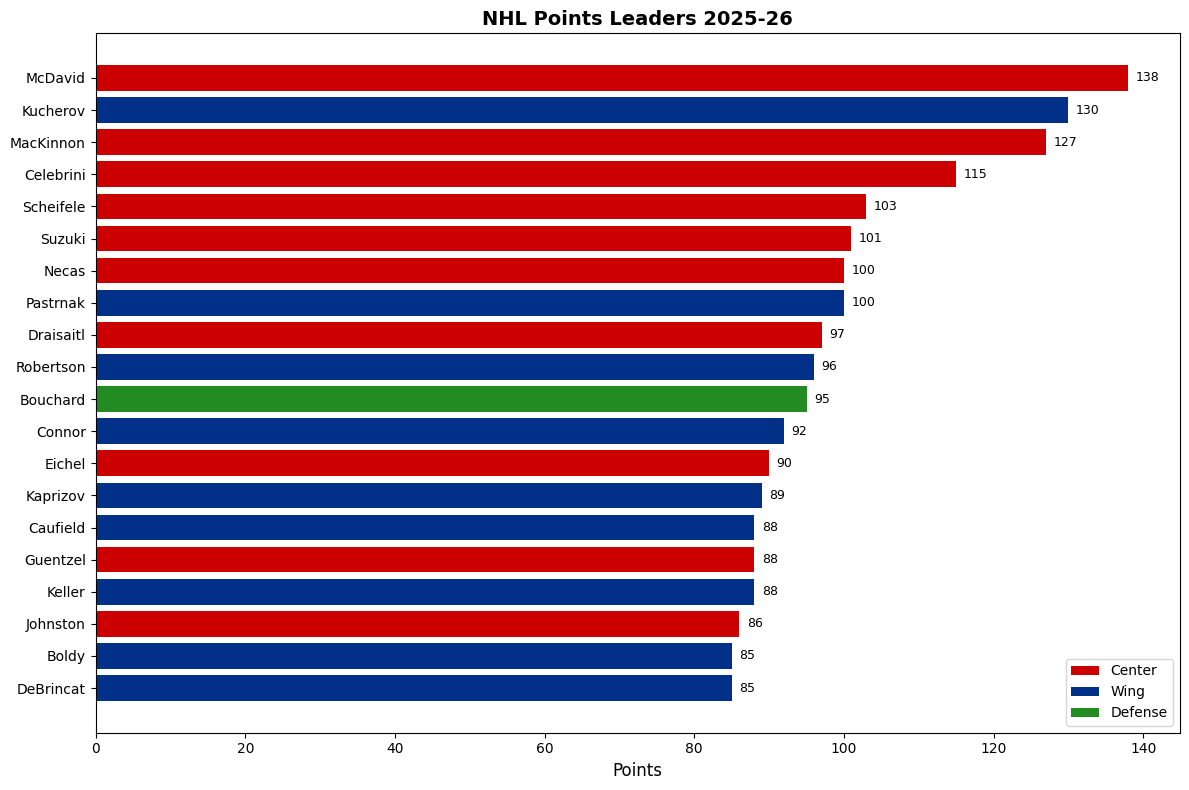

In [30]:
df_top20 = df_player_query.head(20).sort_values('points', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_top20['last_name'], df_top20['points'], color=colors)

ax.set_title('NHL Points Leaders 2025-26', fontsize=14, fontweight='bold')
ax.set_xlabel('Points', fontsize=12)

colors = ['#CC0000' if pos == 'C' else '#003087' if pos == 'L' or pos == 'R' else '#228B22' 
          for pos in df_top20['position']]

for i, val in enumerate(df_top20['points']):
    ax.text(val + 1, i, str(val), va='center', fontsize=9)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='#CC0000', label='Center'),
    Patch(facecolor='#003087', label='Wing'),
    Patch(facecolor='#228B22', label='Defense')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../visuals/05_points_leaders.png', dpi=150, bbox_inches='tight')

plt.show()